In [1]:
suppressPackageStartupMessages({
    library(Seurat)
    library(dplyr)
    library(here)
    library(tibble)
    library(dittoSeq)
    library(stringr)
    library(data.table)
    library(tidyverse)
    library(patchwork) 
    library(RColorBrewer) 
    library(reticulate)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})


source(here("scripts/style.R")) 
source(here("scripts/functions.R")) 

ggplot2::theme_set(theme_min())

Loading required package: viridisLite


Attaching package: ‘magrittr’


The following object is masked from ‘package:purrr’:

    set_names


The following object is masked from ‘package:tidyr’:

    extract


Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


In [ ]:
dmg <- read_csv('data/atac_dmg_atlas_metadata.csv')%>% column_to_rownames('...1')

## All atlas

### CellType

In [ ]:
meta_to_plot <- dmg[,c('CellType', 'ID')]

In [ ]:
my_data <- percentage_data
colnames(my_data) <- c('sample','class','count','percentage')

In [ ]:
sample_grouping <- my_data %>% 
  group_by(sample) %>% 
  slice_max(order_by = percentage) %>% 
  select(class, sample) %>% 
  rename(peak_class = class)

In [8]:
my_data_reordered <- my_data %>% 
  inner_join(sample_grouping, by = "sample") %>% 
  group_by(peak_class) %>% 
  mutate(rank = rank(percentage)) %>%  # rank samples at the level of each peak subtype
  mutate(sample = reorder(sample, -rank)) %>%   # this reorders samples
  ungroup()
  
head(my_data_reordered)

sample,class,count,percentage,peak_class,rank
<fct>,<chr>,<int>,<dbl>,<chr>,<dbl>
GNG,Astrocyte,1166,17.9910508,Differentiated-like,67
GNG,Differentiated-like,2852,44.0055547,Differentiated-like,77
GNG,Endothelial,49,0.7560562,Differentiated-like,40
GNG,Lymphoid,77,1.1880883,Differentiated-like,47
GNG,Mural,231,3.5642648,Differentiated-like,56
GNG,Myeloid,811,12.5135010,Differentiated-like,65


In [10]:
my_data_classified <- my_data_reordered %>%
  group_by(sample) %>%
  summarise(
    Malignant = sum(percentage[class %in% c("Stem-like", "Differentiated-like")]),
    Myeloid = sum(percentage[class == "Myeloid"]),
    Glio_Neuronal = sum(percentage[class %in% c("Neuron", "Astrocyte", "OPC", 'Oligodendrocyte')])
  ) %>%
  mutate(
    Classification = case_when(
      Malignant > 75 ~ "High malignant fraction",
      Malignant > 50 ~ "Intermediate malignant fraction",
      Myeloid > 50 ~ "TAM",
      Glio_Neuronal > 50 ~ "Glio-Neuronal",
      TRUE ~ "Mixed"
    )
  )

In [12]:
# First, we classify the samples
classify_samples <- function(data) {
  data %>%
    group_by(sample) %>%
    summarize(
      Malignant = sum(percentage[class %in% c("Stem-like", "Differentiated-like")]),
      Myeloid = sum(percentage[class == "Myeloid"]),
      Glio_Neuronal = sum(percentage[class %in% c("Neuron", "Astrocyte", "OPC", 'Oligodendrocyte')])
    ) %>%
    mutate(
      Classification = case_when(
        Malignant > 75 ~ "High malignant fraction",
        Malignant > 50 & Malignant < 75 ~ "Intermediate malignant fraction",
        Malignant <= 50 & Myeloid > 50 ~ "TAM",
        Malignant <= 50 & Glio_Neuronal > 40 ~ "Glio-Neuronal",
        TRUE ~ "Mixed"
      )
    ) %>%
    select(sample, Classification)
}

my_data_classified <- classify_samples(my_data_reordered)

In [ ]:
# Determine peak class for reordering within each group
sample_grouping <- my_data %>%
  group_by(sample) %>%
  slice_max(order_by = percentage, n = 1) %>%
  select(class, sample) %>%
  rename(peak_class = class)

# Join the classification with the original data
plot_data <- my_data %>%
  left_join(my_data_classified, by = "sample") %>%
  left_join(sample_grouping, by = "sample")

# Apply the order of classification
class_order <- c("High malignant fraction", "Intermediate malignant fraction", "TAM", 
                 "Glio-Neuronal", "Mixed")

# Reorder samples within each classification based on peak class
plot_data <- plot_data %>%
  group_by(Classification, peak_class) %>%
  mutate(rank = rank(-percentage)) %>%
  ungroup() %>%
  mutate(sample = reorder(sample, rank))

# Define the order of classification
plot_data$Classification <- factor(plot_data$Classification, levels = class_order)

celltype_order <- c('Stem-like','Differentiated-like','OPC','Oligodendrocyte','Astrocyte','Neuron',
                    'Myeloid','Lymphoid','Endothelial','Mural')

plot_data$class <- factor(plot_data$class, levels = celltype_order)

In [20]:
colors_CellType <-c('#742d31','#90474f', 
                  '#c9735e', '#d2a195','#edd1c9',
                  '#feca64',
                  '#3a678a', '#96b1c3',
                  '#507944', '#c8d6c1'
                 )

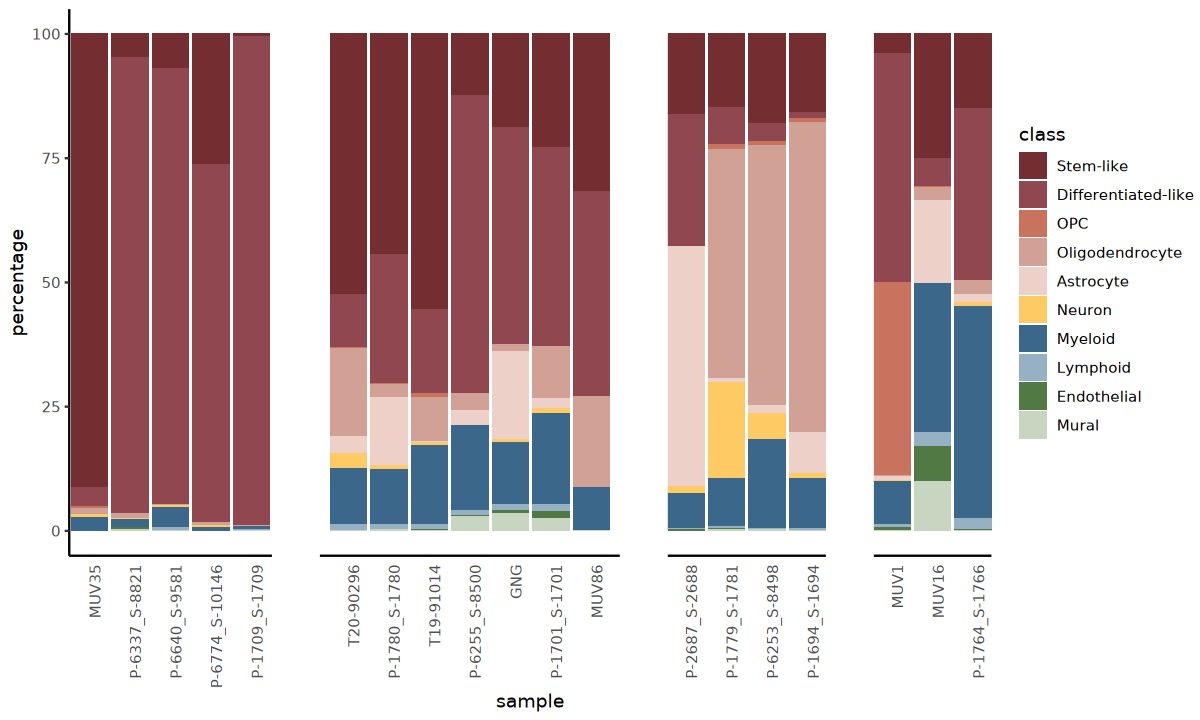

In [21]:
# Plot
ggplot(plot_data, aes(x = sample, y = percentage, fill = class)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values=colors_CellType) +
  facet_grid(~ Classification, space = "free_x", scales = "free_x") +
  scale_x_discrete(expand = c(0.1, 0.1)) + # Adjust space between groups
  theme_classic() +
  theme(
    strip.background = element_blank(),
    strip.text = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1),
    axis.ticks.x = element_blank(),
    panel.spacing.x = unit(2, "lines") # Adjust spacing between panels
  )

In [22]:
ggsave('figures/cell_composition_CellType_dmg_atlas_atac.pdf', height = 5, width = 10)

In [23]:
colors_lvl_1 <- c('#74150f', '#c13814', '#fdc955', '#165884', '#2e5b24')

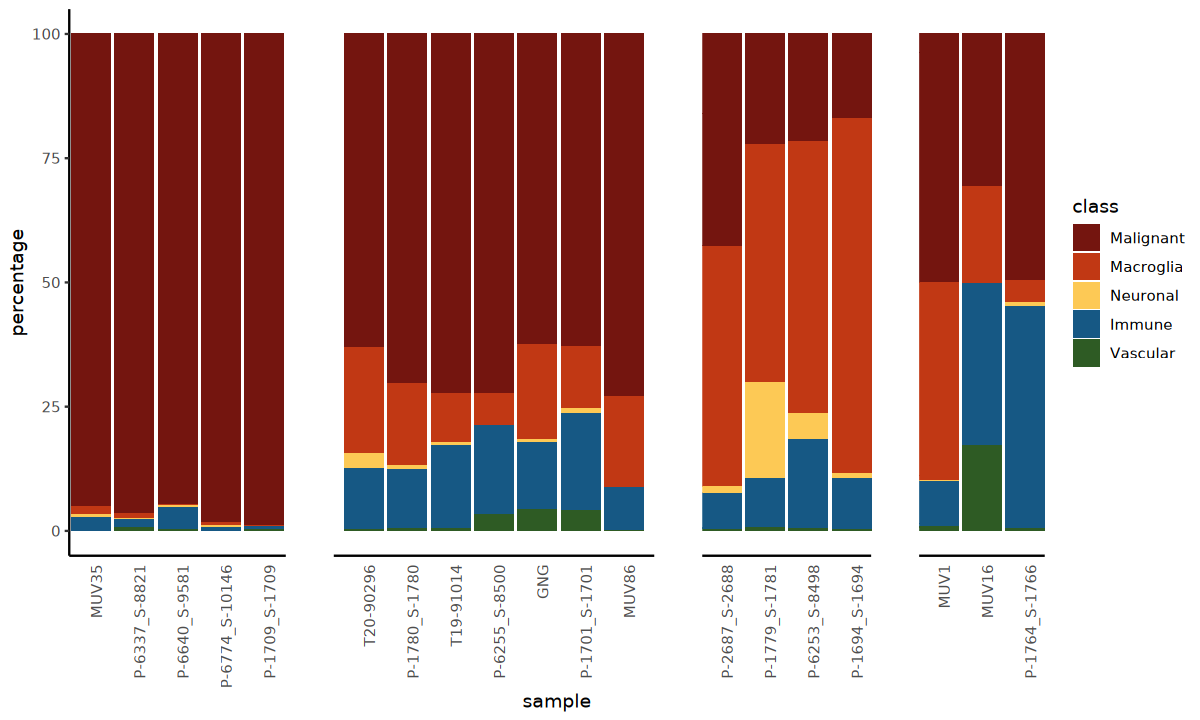

In [24]:
plot_data$class <- recode(plot_data$class,
                   'Astrocyte'='Macroglia',
                    'Differentiated-like'='Malignant',
                    'Endothelial'='Vascular',
                    'Lymphoid'='Immune',
                    'Mural'='Vascular',
                    'Myeloid'='Immune',
                    'Neuron'='Neuronal',
                    'Oligodendrocyte'='Macroglia',
                    'OPC'='Macroglia',
                    'Stem-like'='Malignant'
                   )

# Plot
ggplot(plot_data, aes(x = sample, y = percentage, fill = class)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = colors_lvl_1) +
  facet_grid(~ Classification, space = "free_x", scales = "free_x") +
  scale_x_discrete(expand = c(0.1, 0.1)) + # Adjust space between groups
  theme_classic() +
  theme(
    strip.background = element_blank(),
    strip.text = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1),
    axis.ticks.x = element_blank(),
    panel.spacing.x = unit(2, "lines") # Adjust spacing between panels
  )

In [25]:
ggsave('figures/cell_composition_lvl_1_dmg_atlas_FINAL.pdf', height = 5, width = 9.5)

In [26]:
meta_cohort <- as.data.frame(readxl::read_excel('../../data/dmg_atlas_metadata.xlsx',
                                  sheet = "Metadata"))
meta_cohort

Study,Institute,Preservation_method,ID,Diagnosis,Tumor_type,Tumor_subtype,Location,Source,Clinical_status,⋯,PPM1D,ACVR1,TSHR,BRAF,GNAQ,LMNA,KIT,ARID1A,KRAS,Other
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Ruiz2023,PMC,Cryo,T18-90532,DMG Pons,DMG H3 K27-altered,H3.1 K27-mutant,Pons,Autopsy,Recurrence,⋯,WT,WT,WT,WT,WT,WT,WT,WT,WT,N/A
Ruiz2023,PMC,Cryo,T19-90171,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Autopsy,Recurrence,⋯,WT,WT,WT,WT,WT,WT,WT,WT,WT,N/A
Ruiz2023,PMC,Cryo,T19-91014,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,⋯,WT,WT,WT,WT,WT,WT,WT,WT,WT,N/A
Ruiz2023,PMC,Cryo,T20-01237,DMG Spinal,DMG H3 K27-altered,H3.3 K27-mutant,Spinal,Biopsy,Primary,⋯,WT,WT,WT,WT,WT,WT,WT,WT,WT,N/A
Ruiz2023,PMC,Cryo,T20-90151,DMG Thalamus,DMG H3 K27-altered,H3.3 K27-mutant,Thalamus,Biopsy,Recurrence,⋯,WT,WT,WT,WT,WT,WT,WT,WT,WT,N/A
Ruiz2023,PMC,Cryo,T20-90239,DMG Spinal,DMG H3 K27-altered,H3.3 K27-mutant,Spinal,Biopsy,Recurrence,⋯,WT,WT,WT,WT,WT,WT,WT,WT,WT,N/A
Ruiz2023,PMC,Cryo,T20-90296,DMG Pons,DMG H3 K27-altered,H3.2 K27-mutant,Pons,Biopsy,Primary/Recurrence,⋯,WT,M,WT,WT,WT,WT,WT,WT,WT,FGFR3 overexpression; TP53 inactivation
Ruiz2023,PMC,Cryo,T20-93623,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,⋯,WT,WT,WT,WT,WT,WT,WT,WT,WT,RGMA-ERAS fusion
Ruiz2023,PMC,Cryo/Snap-frozen,T20-93210,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,⋯,WT,WT,WT,WT,WT,WT,WT,WT,WT,N/A


In [27]:
meta_cohort <- meta_cohort %>% filter(ID%in%c('MUV1','MUV16','MUV35','MUV86'))
meta_cohort

Study,Institute,Preservation_method,ID,Diagnosis,Tumor_type,Tumor_subtype,Location,Source,Clinical_status,⋯,PPM1D,ACVR1,TSHR,BRAF,GNAQ,LMNA,KIT,ARID1A,KRAS,Other
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Liu2022,N/A,Fresh,MUV1,DMG Thalamus,DMG H3 K27-altered,H3.3 K27-mutant,Thalamus,N/A,Primary,⋯,WT,WT,WT,M,WT,WT,WT,WT,WT,N/A
Liu2022,N/A,Fresh,MUV35,DMG pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,N/A,Primary,⋯,WT,WT,WT,WT,WT,WT,WT,WT,WT,N/A
Liu2022,N/A,Snap-frozen,MUV16,DMG Thalamus,DMG H3 K27-altered,H3.3 K27-mutant,Thalamus,N/A,Primary,⋯,WT,WT,WT,M,M,WT,WT,WT,WT,N/A
Liu2022,N/A,Fresh,MUV86,DMG pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,N/A,Primary,⋯,WT,WT,WT,WT,WT,WT,WT,WT,WT,N/A


In [28]:
meta_cohort$Diagnosis <- recode(meta_cohort$Diagnosis,
                               `DMG pons` = 'DMG Pons')

In [34]:
meta_cohort$ID <- factor(meta_cohort$ID, levels = unique(meta_cohort$ID))
meta_cohort$Age_years <- as.numeric(meta_cohort$Age_years)

p1 <- meta_cohort %>%
    ggplot(aes(x = ID, y = 1)) +
    geom_tile(aes(fill = Study), colour = "white", width = 0.9, height = 0.9) +
    scale_fill_manual(values = brewer.pal(n = length(unique(meta_cohort$Study)), 
                                          name = "Set3"), 
                      guide = guide_legend(ncol = 2)) +

    theme(
        strip.background = element_blank(), 
        strip.text.x = element_blank())+
    theme_row()

p2 <- meta_cohort %>%
    ggplot(aes(x = ID, y = 1)) +
    geom_tile(aes(fill = Tumor_subtype), colour = "white", width = 0.9, height = 0.9) +
    scale_fill_manual(values = brewer.pal(n = length(unique(meta_cohort$Tumor_subtype)), 
                                          name = "Spectral"), 
                      guide = guide_legend(ncol = 2)) +

    theme(
        strip.background = element_blank(), 
        strip.text.x = element_blank())+
    
    theme_row()

p3 <- meta_cohort %>%
    ggplot(aes(x = ID, y = 1)) +
    geom_tile(aes(fill = Location), colour = "white", width = 0.9, height = 0.9) +
    scale_fill_manual(values = brewer.pal(n = length(unique(meta_cohort$Location)), 
                                 name = "Set2"), 
                      guide = guide_legend(ncol = 2)) +

    theme(
        strip.background = element_blank(), 
        strip.text.x = element_blank())+
    
    theme_row()

p4 <- meta_cohort %>%
    ggplot(aes(x = ID, y = 1)) +
    geom_tile(aes(fill = Age_years), colour = "white", width = 0.9, height = 0.9) +
    scale_fill_gradientn(colours = brewer.pal(9, "YlGnBu"), na.value = "gray90") +
    

    theme(
        strip.background = element_blank(), 
        strip.text.x = element_blank())+
    theme_row()

p5 <- meta_cohort %>%
    ggplot(aes(x = ID, y = 1)) +
    geom_tile(aes(fill = Source), colour = "white", width = 0.9, height = 0.9) +
    scale_fill_manual(values = brewer.pal(n = length(unique(meta_cohort$Source)), 
                                 name = "PiYG"), 
                      guide = guide_legend(ncol = 2)) +

    theme(
        strip.background = element_blank(), 
        strip.text.x = element_blank())+
    
    theme_row()

p6 <- meta_cohort %>%
    ggplot(aes(x = ID, y = 1)) +
    geom_tile(aes(fill = Clinical_status), colour = "white", width = 0.9, height = 0.9) +
    scale_fill_manual(values = brewer.pal(n = length(unique(meta_cohort$Clinical_status)), 
                                 name = "Blues"), 
                      guide = guide_legend(ncol = 2)) +

    theme(
        strip.background = element_blank(), 
        strip.text.x = element_blank())+
    
    theme_row()

p7 <- meta_cohort %>%
    ggplot(aes(x = ID, y = 1)) +
    geom_tile(aes(fill = Isolation_method), colour = "white", width = 0.9, height = 0.9) +
    scale_fill_manual(values = brewer.pal(n = length(unique(meta_cohort$Isolation_method)), 
                                 name = "BrBG"), 
                      guide = guide_legend(ncol = 2)) +

    theme(
        strip.background = element_blank(), 
        strip.text.x = element_blank())+
    
    theme_row()

p8 <- meta_cohort %>%
    ggplot(aes(x = ID, y = 1)) +
    geom_tile(aes(fill = Gender), colour = "white", width = 0.9, height = 0.9) +
    scale_fill_manual(values = brewer.pal(n = length(unique(meta_cohort$Gender)), 
                                 name = "BuPu"), 
                      guide = guide_legend(ncol = 3)) +

    theme(
        strip.background = element_blank(), 
        strip.text.x = element_blank())+
    
    theme_row()

p9 <- meta_cohort %>%
    ggplot(aes(x = ID, y = 1)) +
    geom_tile(aes(fill = Sc_multiome), colour = "white", width = 0.9, height = 0.9) +
    scale_fill_manual(values = brewer.pal(n = length(unique(meta_cohort$Sc_multiome)), 
                                 name = "Greens"), 
                      guide = guide_legend(ncol = 2)) +
    theme(panel.border = element_blank(),
          axis.text.y = element_blank(),
          axis.title.y = element_blank(),
          axis.ticks = element_blank(),
          strip.background = element_blank(), 
          strip.text.x = element_blank()) +
    rotate_x()

Warning message in brewer.pal(n = length(unique(meta_cohort$Study)), name = "Set3"):
“minimal value for n is 3, returning requested palette with 3 different levels
”
Warning message in brewer.pal(n = length(unique(meta_cohort$Tumor_subtype)), name = "Spectral"):
“minimal value for n is 3, returning requested palette with 3 different levels
”
Warning message in brewer.pal(n = length(unique(meta_cohort$Location)), name = "Set2"):
“minimal value for n is 3, returning requested palette with 3 different levels
”
Warning message in brewer.pal(n = length(unique(meta_cohort$Source)), name = "PiYG"):
“minimal value for n is 3, returning requested palette with 3 different levels
”
Warning message in brewer.pal(n = length(unique(meta_cohort$Clinical_status)), name = "Blues"):
“minimal value for n is 3, returning requested palette with 3 different levels
”
Warning message in brewer.pal(n = length(unique(meta_cohort$Isolation_method)), :
“minimal value for n is 3, returning requested palette with 3

In [35]:
meta_cohort$TP53 <- recode(meta_cohort$TP53,
                          'Loss'='M')
meta_cohort$PDGFRA <- recode(meta_cohort$PDGFRA,
                          'Amp'='M',
                            'M & Amp' = 'M')

In [36]:
variables <- c('H3F3A', 'H3C3', 'HIST1H3B', 'HIST2H3C', 'TP53', 'EGFR', 'PDGFRA', 'SUFU', 'NF1', 'pTERT', 
               'PIK3CA', 'PIK3R1', 'ATRX', 'PTEN', 'ASXL1', 'BCOR', 'BCORL1', 'SMC1A', 'WT1', 'PPM1D', 
               'ACVR1', 'TSHR', 'BRAF')

plots <- list()

for (variable in variables) {
    plot <- meta_cohort %>%
        ggplot(aes(x = ID, y = 1)) +
        geom_tile(aes(fill = !!sym(variable)), colour = "white", width = 0.9, height = 0.9) +
        scale_fill_manual(values = c('#686868','#ffffff','#e2e2e2'), 
                          guide = guide_legend(ncol = 3)) +
        theme(
        strip.background = element_blank(), 
        strip.text.x = element_blank())+
        theme_row()
    
    plots[[paste0("p", which(variables == variable) + 9)]] <- plot
}


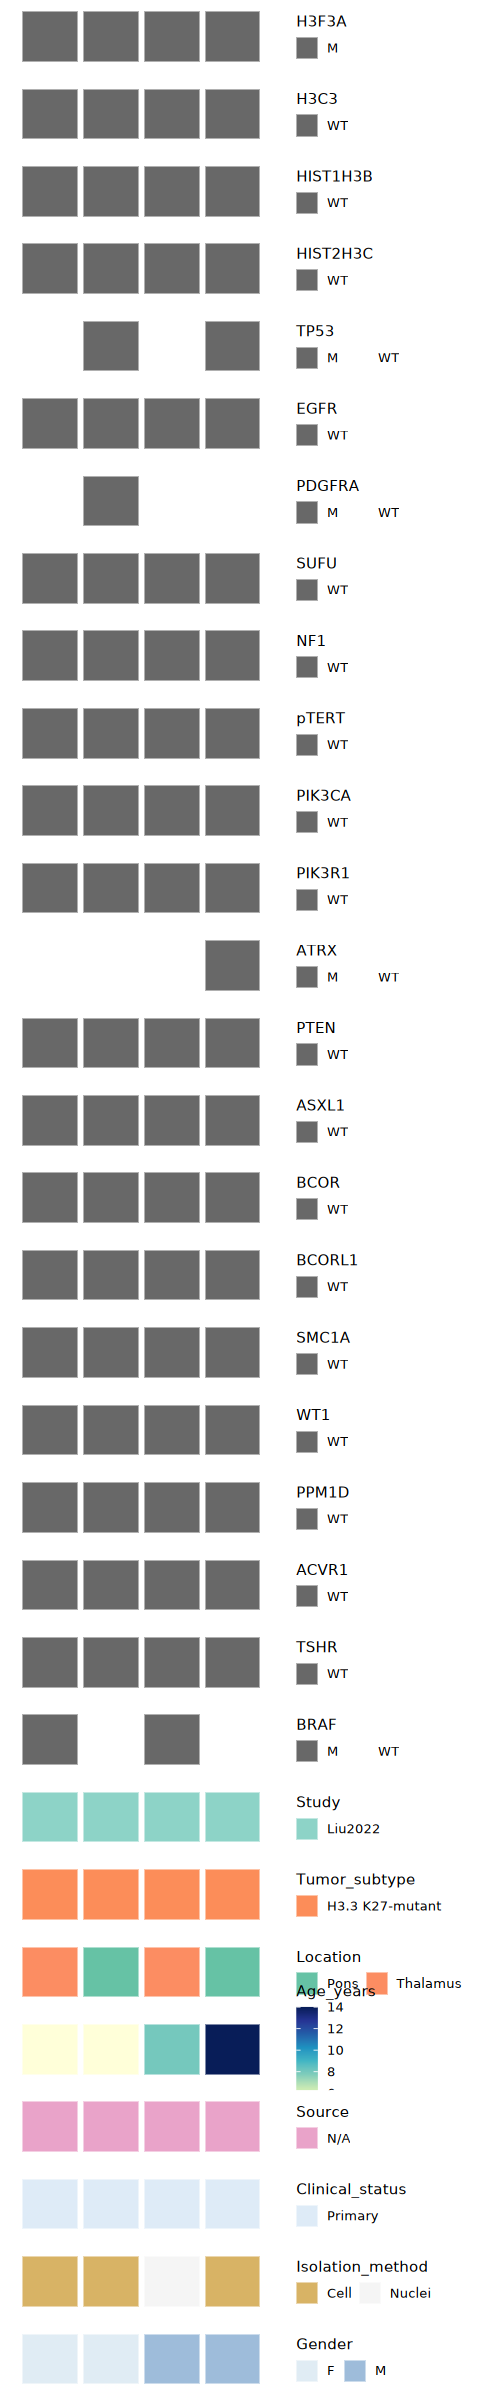

In [37]:
options(repr.plot.height = 20, repr.plot.width = 4)
cowplot::plot_grid(plots$p10, plots$p11, plots$p12, plots$p13, plots$p14, 
                   plots$p15, plots$p16, plots$p17, plots$p18, plots$p19,
                   plots$p20, plots$p21, plots$p22, plots$p23, plots$p24, 
                   plots$p25, plots$p26, plots$p27, plots$p28, plots$p29, 
                   plots$p30, plots$p31, plots$p32,
                   p1, p2, p3, p4, p5, p6, p7, p8, 
                   align = "v", axis = "r", ncol = 1,
                   rel_heights = c(rep(0.08, 40), 0.2))

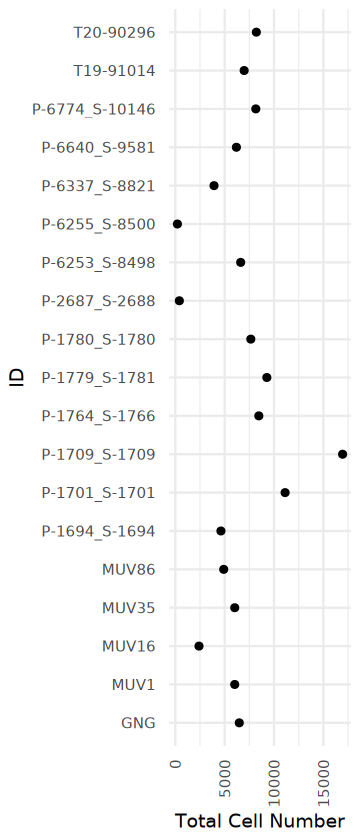

In [40]:
# Calculate the number of cells per ID
cell_counts <- table(dmg$ID)

# Convert to data frame
counts_df <- as.data.frame(cell_counts)
colnames(counts_df) <- c("ID", "Number_of_Cells")

options(repr.plot.height = 7, repr.plot.width = 3)
# Create the dot plot with gaps between groups
ggplot(counts_df, aes(x=ID, y=Number_of_Cells)) +
  geom_point(stat="identity") +
  theme_minimal() +
  labs(x = "ID", y = "Total Cell Number") +
  coord_flip() + # Flip the coordinates if you want the IDs on the y-axis
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.text.x.top = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.length = unit(0.2, "cm")
  )